In [2]:
# ENTIRE COVID SYMPTOMS PROJECT IN PYTHON
# =========================================================

import pandas as pd
import numpy as np
import itertools
import warnings
import matplotlib.pyplot as plt
import networkx as nx
import shap

from sklearn.linear_model import LogisticRegressionCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")


In [4]:
# =========================================================
# 1. LOAD DATA
# =========================================================
file_path = r"C:\Users\vamsi\Downloads\merged.csv"   # change if needed
data = pd.read_csv(file_path)

# =========================================================
# 2. CLEAN COLUMN NAMES
# =========================================================
data.columns = [c.strip().lower() for c in data.columns]

# =========================================================
# 3. RENAME COLUMNS ACCORDING TO YOUR PROJECT
# =========================================================
data = data.rename(columns={
    'aches': 'Aches',
    'age': 'age',
    'chest_pain': 'ChestPain',
    'chills': 'Chills',
    'conjunctivitis': 'RedEye',
    'cough': 'Cough',
    'diarrhea': 'Diarrhea',
    'disease': 'COVID',
    'fatigue': 'Fatigue',
    'fever': 'Fever',
    'gender': 'gender',
    'headache': 'Headache',
    'nausea': 'Nausea',
    'running_nose': 'RunnyNose',
    'short_breath': 'ShortBreath',
    'vomiting': 'Vomit',
    'wheezing': 'Wheeze'
})

# =========================================================
# 4. KEEP ONLY REQUIRED COLUMNS
# =========================================================
cols = [
    'Aches', 'age', 'ChestPain', 'Chills', 'RedEye', 'Cough',
    'Diarrhea', 'COVID', 'Fatigue', 'Fever', 'gender',
    'Headache', 'Nausea', 'RunnyNose', 'ShortBreath',
    'Vomit', 'Wheeze'
]

data = data[cols].copy()

# =========================================================
# 5. CLEAN VALUES
# =========================================================
# age continuous
data['age'] = pd.to_numeric(data['age'], errors='coerce')
data['age'] = data['age'].fillna(data['age'].median())

# all other variables binary
for col in data.columns:
    if col != 'age':
        data[col] = pd.to_numeric(data[col], errors='coerce')
        data[col] = data[col].fillna(0)
        data[col] = (data[col] > 0).astype(int)

print("=========================================================")
print("UNIQUE VALUES IN EACH COLUMN")
print("=========================================================")
for col in data.columns:
    print(col, ":", sorted(data[col].unique()))

print("\n=========================================================")
print("COVID COUNTS")
print("=========================================================")
print(data["COVID"].value_counts())

# =========================================================
# 6. RUN LASSO / LOGISTIC LASSO FOR ALL VARIABLES
# =========================================================
variables = list(data.columns)

edges = []
results = []

for target in variables:
    predictors = [v for v in variables if v != target]

    X = data[predictors].copy()
    y = data[target].copy()

    if y.nunique() <= 1:
        print(f"Skipping {target} because it has only one unique value")
        continue

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # -----------------------------------------------------
    # BINARY TARGET -> LOGISTIC LASSO
    # -----------------------------------------------------
    if y.nunique() == 2:
        model = LogisticRegressionCV(
            cv=5,
            penalty='l1',
            solver='liblinear',
            max_iter=5000
        )
        model.fit(X_scaled, y)

        coef = model.coef_[0]

        # McFadden pseudo R2
        p = np.clip(model.predict_proba(X_scaled)[:, 1], 1e-10, 1 - 1e-10)
        ll_full = np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

        p_null = np.repeat(y.mean(), len(y))
        p_null = np.clip(p_null, 1e-10, 1 - 1e-10)
        ll_null = np.sum(y * np.log(p_null) + (1 - y) * np.log(1 - p_null))

        score = 1 - (ll_full / ll_null)
        score_name = "McFadden_R2"

    # -----------------------------------------------------
    # CONTINUOUS TARGET -> LASSO
    # -----------------------------------------------------
    else:
        model = LassoCV(cv=5, max_iter=10000)
        model.fit(X_scaled, y)

        coef = model.coef_
        pred = model.predict(X_scaled)
        score = r2_score(y, pred)
        score_name = "R2"

    # -----------------------------------------------------
    # KEEP COEFFICIENTS WITH ABSOLUTE VALUE > 0.05
    # -----------------------------------------------------
    kept = []
    for pred_name, c in zip(predictors, coef):
        if abs(c) > 0.05:
            edges.append((pred_name, target, float(c)))
            kept.append((pred_name, round(float(c), 3)))

    row = {
        "Target": target,
        "Parents": kept,
        "Num_Parents": len(kept)
    }
    row[score_name] = round(float(score), 4)

    results.append(row)

results_df = pd.DataFrame(results)

print("\n=========================================================")
print("REGRESSION RESULTS")
print("=========================================================")
print(results_df)

# =========================================================

UNIQUE VALUES IN EACH COLUMN
Aches : [0, 1]
age : [0.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0]
ChestPain : [0, 1]
Chills : [0, 1]
RedEye : [0, 1]
Cough : [0, 1]
Diarrhea : [0, 1]
COVID : [0, 1]
Fatigue : [0, 1]
Fever : [0, 1]
gender : [0, 1]
Headache : [0, 1]
Nausea : [0, 1]
RunnyNose : [0, 1]
ShortBreath : [0, 1]
Vomit : [0, 1]
Wheeze : [0, 1]

COVID COUNTS
COVID
1    3659
0     885
Name: count, dtype: int64

REGRESSION RESULTS
         Target                                            Parents  \
0         Aches  [(age, 0.276), (Chills, 0.685), (RedEye, -0.42...   
1           age                                                 []   
2     ChestPain                                                 []   
3        Chills  [(Aches, 0.736), (age, 0.133), (ChestPain, 0.2...   
4        RedEye  [(Aches, -0.553), (age, 0.264), (Chills, 1.529...   
5         Cough  [(Aches, 0.487), (age, 0.172), (ChestPain, 0.2...   
6      Diarrhea                                                 []  


STRONG TARGETS KEPT
{'Cough', 'Headache', 'Fatigue', 'Vomit', 'RedEye', 'Fever', 'RunnyNose', 'ShortBreath', 'Nausea', 'Aches', 'Chills'}

FILTERED EDGES
('age', 'Aches', 0.2757246006425887)
('Chills', 'Aches', 0.6850287413177376)
('RedEye', 'Aches', -0.4231779254133947)
('Cough', 'Aches', 0.6084265610884837)
('Diarrhea', 'Aches', 0.09222839801418183)
('COVID', 'Aches', 0.23673265247684636)
('Fatigue', 'Aches', 0.8609100807749441)
('Fever', 'Aches', 0.22118028206886856)
('gender', 'Aches', -0.09074651194404561)
('Headache', 'Aches', 0.6114064725490237)
('Nausea', 'Aches', 0.14865535936882038)
('ShortBreath', 'Aches', -0.07892817360600123)
('Vomit', 'Aches', -0.12459110676414953)
('Wheeze', 'Aches', 0.1692717040720854)
('Aches', 'Chills', 0.7358337084230481)
('age', 'Chills', 0.13336035820332978)
('ChestPain', 'Chills', 0.2639100225132312)
('RedEye', 'Chills', 1.4106061815655637)
('Cough', 'Chills', -0.05929205757981987)
('Fatigue', 'Chills', 0.26613372293842813)
('Fever', 'Chills', -0

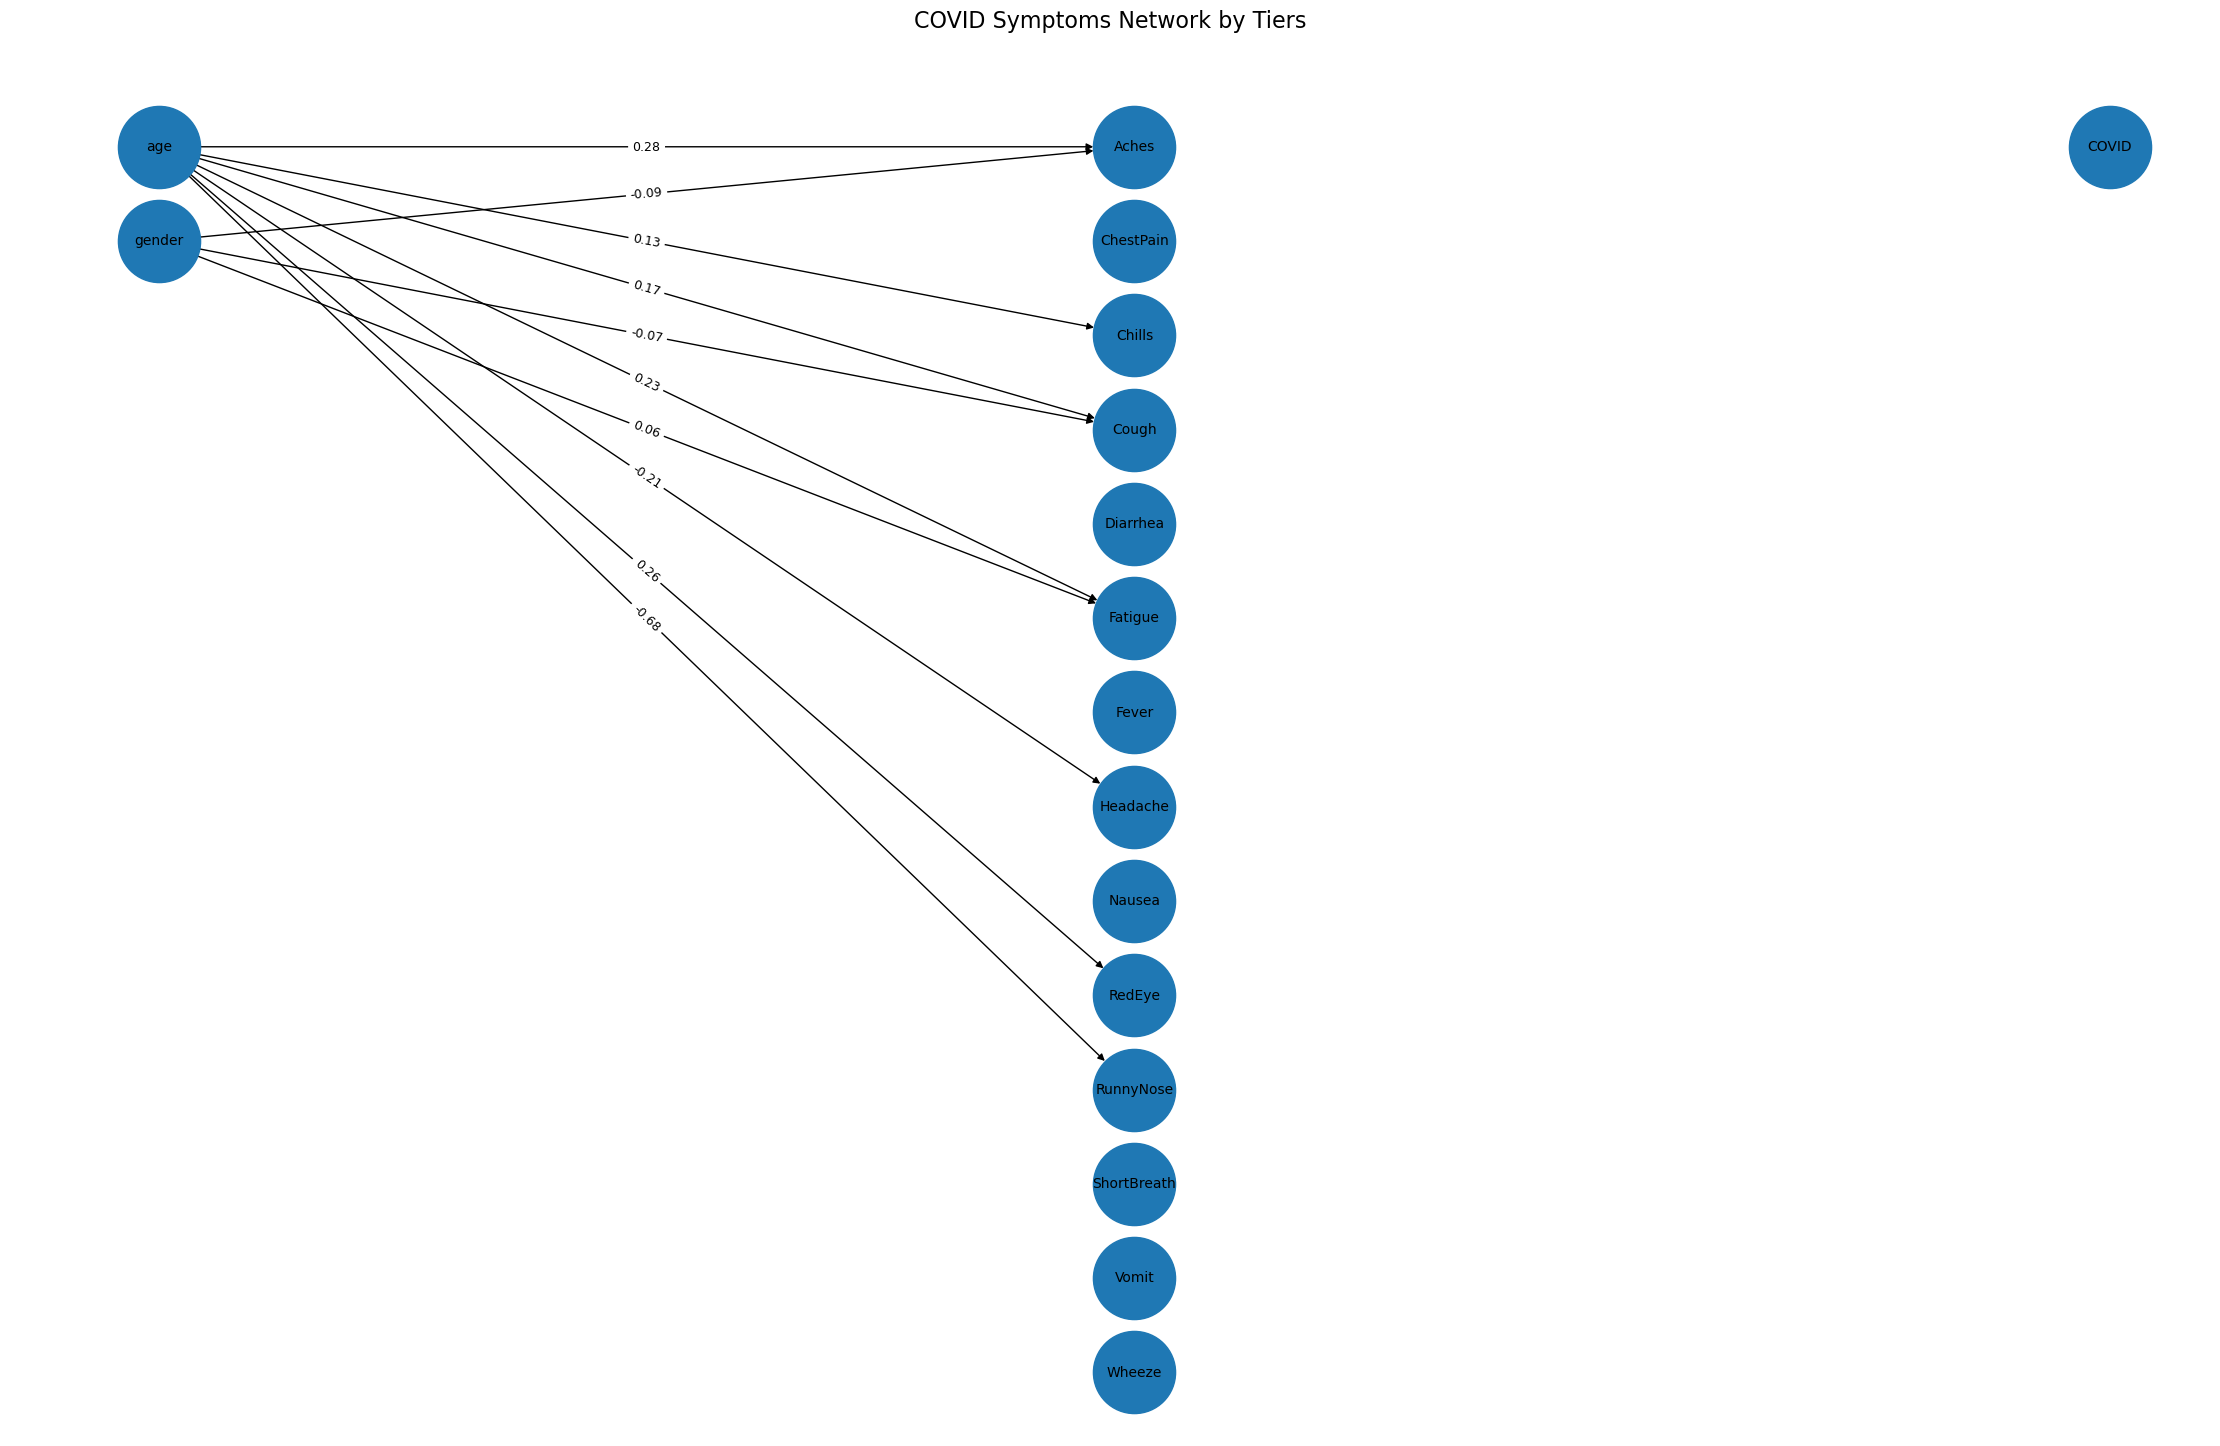

In [6]:
# 7. KEEP ONLY STRONG EQUATIONS
#    RULE: R2 or McFadden_R2 >= 0.10
# =========================================================
strong_targets = set()

for _, row in results_df.iterrows():
    if "McFadden_R2" in row and pd.notna(row.get("McFadden_R2", np.nan)):
        if row["McFadden_R2"] >= 0.10:
            strong_targets.add(row["Target"])

    if "R2" in row and pd.notna(row.get("R2", np.nan)):
        if row["R2"] >= 0.10:
            strong_targets.add(row["Target"])

filtered_edges = [(u, v, c) for (u, v, c) in edges if v in strong_targets]

print("\n=========================================================")
print("STRONG TARGETS KEPT")
print("=========================================================")
print(strong_targets)

print("\n=========================================================")
print("FILTERED EDGES")
print("=========================================================")
for e in filtered_edges:
    print(e)

# =========================================================
# 8. BUILD NETWORK BY TIERS
# =========================================================
tier = {
    'age': 0,
    'gender': 0,

    'Aches': 1,
    'ChestPain': 1,
    'Chills': 1,
    'RedEye': 1,
    'Cough': 1,
    'Diarrhea': 1,
    'Fatigue': 1,
    'Fever': 1,
    'Headache': 1,
    'Nausea': 1,
    'RunnyNose': 1,
    'ShortBreath': 1,
    'Vomit': 1,
    'Wheeze': 1,

    'COVID': 2
}

G = nx.DiGraph()

for col in data.columns:
    G.add_node(col, tier=tier[col])

for u, v, c in filtered_edges:
    if tier[u] < tier[v]:
        G.add_edge(u, v, weight=c)

print("\n=========================================================")
print("IS GRAPH A DAG?")
print("=========================================================")
print(nx.is_directed_acyclic_graph(G))

print("\n=========================================================")
print("GRAPH EDGES")
print("=========================================================")
print(list(G.edges(data=True)))

# =========================================================
# 9. DRAW NETWORK BY TIERS
# =========================================================
tier_nodes = {}
for node in G.nodes():
    t = G.nodes[node]['tier']
    tier_nodes.setdefault(t, []).append(node)

pos = {}
x_gap = 3
y_gap = 1.6

for t in sorted(tier_nodes.keys()):
    nodes = sorted(tier_nodes[t])
    for i, node in enumerate(nodes):
        pos[node] = (t * x_gap, -i * y_gap)

plt.figure(figsize=(22, 14))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3500,
    font_size=10,
    arrows=True
)

edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("COVID Symptoms Network by Tiers", fontsize=16)
plt.axis("off")
plt.show()


In [8]:
# =========================================================
# 10. FUNCTION TO FIND PARENTS / CHILDREN / MARKOV BLANKET
# =========================================================
def show_node_info(node_name, graph):
    parents = list(graph.predecessors(node_name))
    children = list(graph.successors(node_name))

    markov_blanket = set(parents + children)
    for child in children:
        markov_blanket.update(list(graph.predecessors(child)))

    markov_blanket.discard(node_name)

    print(f"\nNode: {node_name}")
    print("Parents:", parents)
    print("Children:", children)
    print("Markov blanket:", sorted(markov_blanket))

# examples
show_node_info("Fever", G)
show_node_info("Chills", G)
show_node_info("COVID", G)


Node: Fever
Parents: []
Children: []
Markov blanket: []

Node: Chills
Parents: ['age']
Children: []
Markov blanket: ['age']

Node: COVID
Parents: []
Children: []
Markov blanket: []


In [10]:
# 11. CPT ESTIMATION (PYTHON REPLACEMENT FOR NETICA TABLES)
# =========================================================
def estimate_cpt(df, target, parents):
    if len(parents) == 0:
        return pd.DataFrame({f"P({target}=1)": [df[target].mean()]})

    rows = []
    for combo in itertools.product([0, 1], repeat=len(parents)):
        temp = df.copy()
        for p, val in zip(parents, combo):
            temp = temp[temp[p] == val]

        prob = temp[target].mean() if len(temp) > 0 else np.nan

        row = {p: val for p, val in zip(parents, combo)}
        row[f"P({target}=1)"] = prob
        rows.append(row)

    return pd.DataFrame(rows)

print("\n=========================================================")
print("CPT TABLES")
print("=========================================================")
for node in G.nodes():
    if node != 'age':
        parents = list(G.predecessors(node))
        print(f"\nCPT for {node}")
        print(estimate_cpt(data, node, parents))


CPT TABLES

CPT for Aches
   age  gender  P(Aches=1)
0    0       0    0.164349
1    0       1    0.160055
2    1       0         NaN
3    1       1         NaN

CPT for ChestPain
   P(ChestPain=1)
0        0.034771

CPT for Chills
   age  P(Chills=1)
0    0     0.141261
1    1          NaN

CPT for RedEye
   age  P(RedEye=1)
0    0     0.022339
1    1          NaN

CPT for Cough
   age  gender  P(Cough=1)
0    0       0    0.379267
1    0       1    0.395349
2    1       0         NaN
3    1       1         NaN

CPT for Diarrhea
   P(Diarrhea=1)
0       0.060519

CPT for COVID
   P(COVID=1)
0    0.805238

CPT for Fatigue
   age  gender  P(Fatigue=1)
0    0       0      0.173198
1    0       1      0.168263
2    1       0           NaN
3    1       1           NaN

CPT for Fever
   P(Fever=1)
0    0.421215

CPT for gender
   P(gender=1)
0     0.463248

CPT for Headache
   age  P(Headache=1)
0    0       0.166886
1    1            NaN

CPT for Nausea
   P(Nausea=1)
0     0.105414

CPT 

In [12]:
# 12. OVERALL PROBABILITY OF COVID
# =========================================================
p_covid = data["COVID"].mean()
print("\n=========================================================")
print("OVERALL PROBABILITY OF COVID POSITIVE")
print("=========================================================")
print(round(p_covid, 4))



OVERALL PROBABILITY OF COVID POSITIVE
0.8052


In [14]:
# 13. FINAL COVID PREDICTION MODEL
# =========================================================
target = "COVID"
features = [c for c in data.columns if c != target]

X = data[features].copy()
y = data[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

covid_model = LogisticRegressionCV(
    cv=5,
    penalty='l1',
    solver='liblinear',
    scoring='roc_auc',
    max_iter=5000
)

covid_model.fit(X_train_scaled, y_train)

pred_prob = covid_model.predict_proba(X_test_scaled)[:, 1]
pred = (pred_prob >= 0.5).astype(int)

print("\n=========================================================")
print("FINAL COVID MODEL PERFORMANCE")
print("=========================================================")
print("AUC:", round(roc_auc_score(y_test, pred_prob), 4))
print(classification_report(y_test, pred))



FINAL COVID MODEL PERFORMANCE
AUC: 0.8015
              precision    recall  f1-score   support

           0       0.61      0.29      0.39       177
           1       0.85      0.96      0.90       732

    accuracy                           0.83       909
   macro avg       0.73      0.62      0.65       909
weighted avg       0.80      0.83      0.80       909



In [16]:
# 14. TEST ONE NEW CASE
# =========================================================
new_case_dict = {
    'Aches': 1,
    'age': 45,
    'ChestPain': 0,
    'Chills': 1,
    'RedEye': 0,
    'Cough': 1,
    'Diarrhea': 0,
    'Fatigue': 1,
    'Fever': 1,
    'gender': 1,
    'Headache': 1,
    'Nausea': 0,
    'RunnyNose': 1,
    'ShortBreath': 0,
    'Vomit': 0,
    'Wheeze': 0
}

new_case = pd.DataFrame([new_case_dict])[features]
new_case_scaled = scaler_final.transform(new_case)
new_case_prob = covid_model.predict_proba(new_case_scaled)[0, 1]

print("\n=========================================================")
print("PREDICTED COVID PROBABILITY FOR TEST CASE")
print("=========================================================")
print(round(new_case_prob, 4))



PREDICTED COVID PROBABILITY FOR TEST CASE
0.9105



Generating SHAP summary plot...


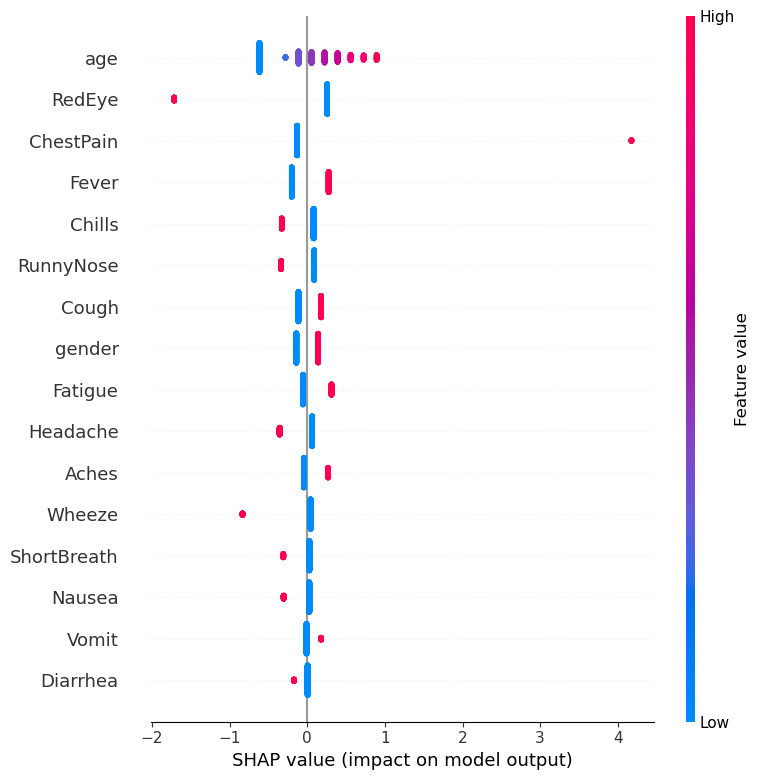


Generating SHAP explanation for test case...


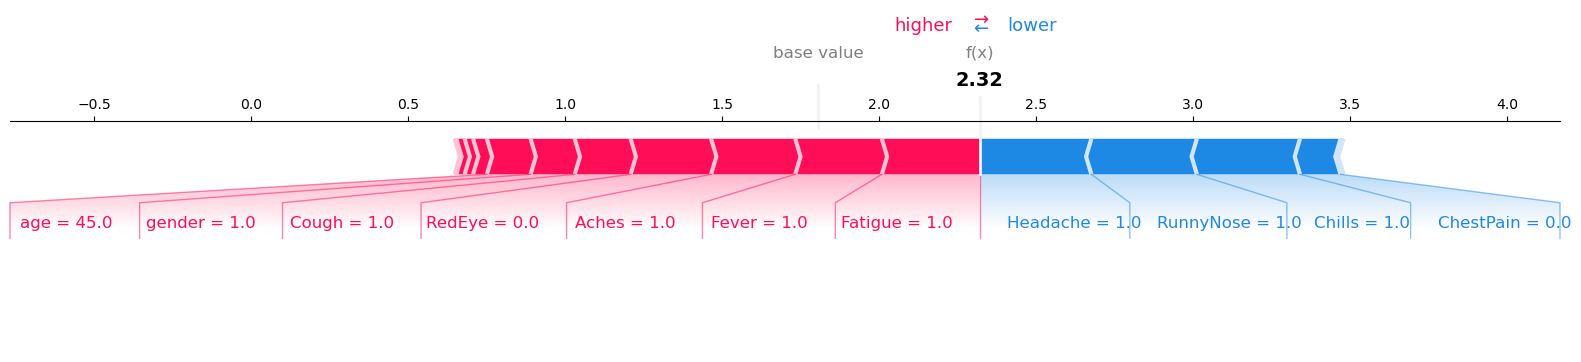

In [18]:
# 15. SHAP EXPLAINABILITY
# =========================================================
explainer = shap.LinearExplainer(covid_model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

print("\nGenerating SHAP summary plot...")
shap.summary_plot(shap_values, X_test, feature_names=features)

print("\nGenerating SHAP explanation for test case...")
one_case_shap = explainer.shap_values(new_case_scaled)

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    one_case_shap[0],
    new_case,
    feature_names=features,
    matplotlib=True
)


In [20]:
# 16. SIMPLE REASONING TEXT
# =========================================================
coef_series = pd.Series(covid_model.coef_[0], index=features)

def explain_case(case_df, model, scaler, coef_series, top_n=5):
    case_scaled = scaler.transform(case_df)
    prob = model.predict_proba(case_scaled)[0, 1]

    contributions = pd.Series(case_scaled[0], index=features) * coef_series
    contributions = contributions.sort_values(key=np.abs, ascending=False)

    top = contributions.head(top_n)

    lines = []
    for feat, val in top.items():
        direction = "increased" if val > 0 else "decreased"
        lines.append(f"{feat}={case_df.iloc[0][feat]} {direction} the COVID prediction")

    text = f"Predicted probability of COVID is {prob:.3f}. Main reasons: " + "; ".join(lines) + "."
    return text

print("\n=========================================================")
print("REASONING FOR TEST CASE")
print("=========================================================")
print(explain_case(new_case, covid_model, scaler_final, coef_series))

# =========================================================


REASONING FOR TEST CASE
Predicted probability of COVID is 0.910. Main reasons: Headache=1 decreased the COVID prediction; RunnyNose=1 decreased the COVID prediction; Chills=1 decreased the COVID prediction; Fatigue=1 increased the COVID prediction; Fever=1 increased the COVID prediction.


In [22]:
results_df.to_csv(r"C:\Users\vamsi\Downloads\covid_lasso_results.csv", index=False)

edge_df = pd.DataFrame(filtered_edges, columns=["Parent", "Child", "Coefficient"])
edge_df.to_csv(r"C:\Users\vamsi\Downloads\covid_network_edges.csv", index=False)

print("\nFiles saved:")
print(r"C:\Users\vamsi\Downloads\covid_lasso_results.csv")
print(r"C:\Users\vamsi\Downloads\covid_network_edges.csv")


Files saved:
C:\Users\vamsi\Downloads\covid_lasso_results.csv
C:\Users\vamsi\Downloads\covid_network_edges.csv
